- Transformed 
- includes drop out, no reguralization 


In [1]:
# Imports
###BEGIN library importing+
import tensorflow as tf
import matplotlib.pyplot as plt
import sys
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from tensorflow.keras.optimizers import SGD
import tensorflow as tf
from tensorflow.keras import Sequential, layers
import keras_tuner as kt
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from sklearn.model_selection import train_test_split
from code_files.data_preperation import prepare_for_train
import pandas as pd
import numpy as np

In [2]:
# Load Dataset
df_amazon = pd.read_csv("../dataset/eda_amazon_sales_report.csv")
df_amazon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117123 entries, 0 to 117122
Data columns (total 24 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Unnamed: 0                           117123 non-null  int64  
 1   Size                                 117123 non-null  int64  
 2   Qty                                  117123 non-null  int64  
 3   Amount                               117123 non-null  float64
 4   promotion-ids                        117123 non-null  int64  
 5   B2B                                  117123 non-null  int64  
 6   Status_Cancelled                     117123 non-null  bool   
 7   Status_Shipped                       117123 non-null  bool   
 8   Status_Shipped - Delivered to Buyer  117123 non-null  bool   
 9   Fulfilment_Amazon                    117123 non-null  bool   
 10  Fulfilment_Merchant                  117123 non-null  bool   
 11  ship-service-

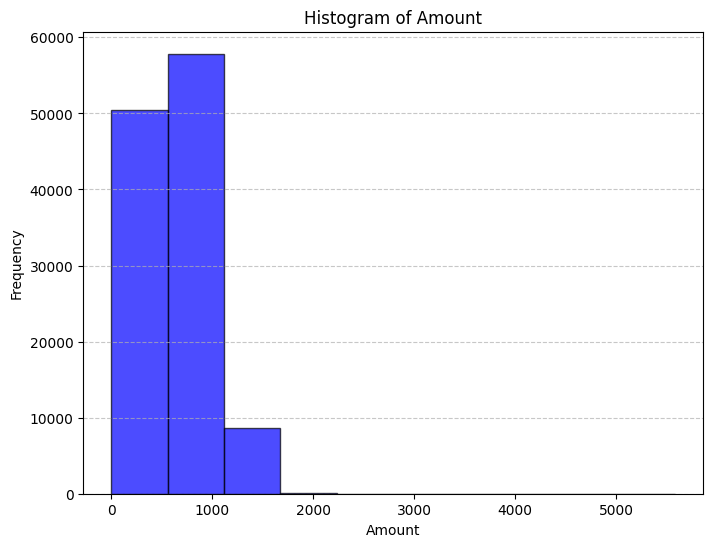

In [3]:
# Histogram of the Response Variable 

plt.figure(figsize=(8, 6))
plt.hist(df_amazon['Amount'], bins=10, color='blue', edgecolor='black', alpha=0.7)
plt.title('Histogram of Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [4]:
# Transformation using yeo johnson 
from scipy import stats
df_amazon['Amount'], _ = stats.yeojohnson(df_amazon['Amount'])

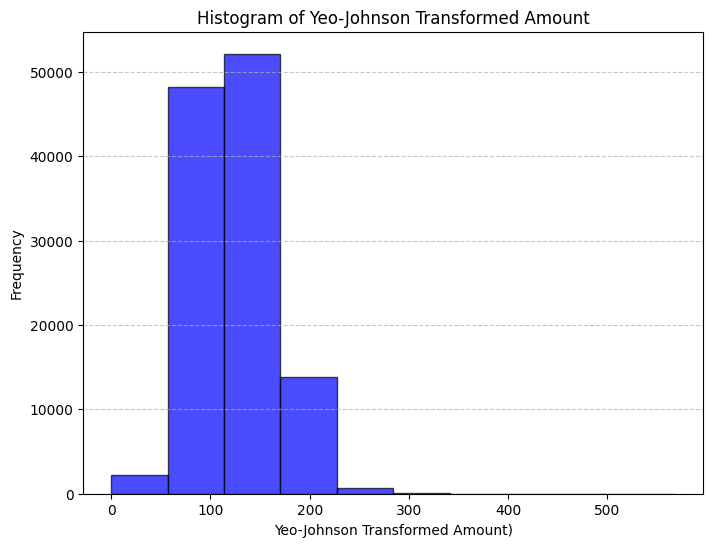

In [ ]:
# Histogram for transformed Response Variable 

# Plot the histogram of the Yeo-Johnson-transformed data
plt.figure(figsize=(8, 6))
plt.hist(df_amazon['Amount'], bins=10, color='blue', edgecolor='black', alpha=0.7)
plt.title('Histogram of Yeo-Johnson Transformed Amount')
plt.xlabel('Yeo-Johnson Transformed Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [178]:
# Split and Prepare for train
dftrain, dftest = train_test_split(df_amazon, test_size=0.1, random_state=42)
Xtrain_prepared, ytrain_prepared, Xtest_prepared, ytest_prepared = prepare_for_train(dftrain, dftest)

Xtrain_prepared, Xdev_prepared, ytrain_prepared, ydev_prepared = train_test_split(Xtrain_prepared, ytrain_prepared,
                                                                                  test_size=0.2, random_state=42)


print("Train shape: ", Xtrain_prepared.shape, ytrain_prepared.shape)
print("Dev shape: ", Xdev_prepared.shape, ydev_prepared.shape)
print("Test shape: ", Xtest_prepared.shape, ytest_prepared.shape)

Train shape:  (83216, 7) (83216,)
Dev shape:  (20804, 7) (20804,)
Test shape:  (11713, 7) (11713,)


In [ ]:
# Random Search Hypertuning 

import tensorflow as tf
import matplotlib.pyplot as plt
import keras_tuner as kt

def build_model(hp):

  n_hidden = hp.Int("n_hidden", min_value=2, max_value=10, default=2)
  learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=0.9,
                                  sampling="log")
  optimizer = hp.Choice("optimizer", values=["sgd", "adam", "adagrad","rms", "adadelta", 
                                             "adamax", "nadam"])

  if optimizer == "sgd":
    optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
  elif optimizer == "adam":
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
  elif optimizer == "adagrad":
    optimizer = tf.keras.optimizers.Adagrad(learning_rate=learning_rate)
  elif optimizer == "rms": 
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
  elif optimizer == "adadelta":
    optimizer = tf.keras.optimizers.Adadelta(learning_rate=learning_rate)
  elif optimizer == "adamax":
    optimizer = tf.keras.optimizers.Adamax(learning_rate=learning_rate)
  elif optimizer == "ftrl":
    optimizer = tf.keras.optimizers.Ftrl(learning_rate=learning_rate)
  elif optimizer == "nadam": 
    optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
  

  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Flatten())
  for _ in range(n_hidden):
    model.add(tf.keras.layers.Dense(units = hp.Int("n_neurons", min_value=100, max_value=900, step = 50, sampling = "log"),
                                    activation=hp.Choice("activation", values = ["relu", "tanh", "selu", "linear", "swish",
                                                                                 "softplus", "exponential"]))
                                                                                 )
    model.add(layers.Dropout(rate=hp.Float("dropout_rate", min_value=0.1, max_value=0.9, step=0.1)))


  model.add(layers.Dense(1, activation='linear'))
  model.compile(
        loss='mse',
        optimizer=optimizer,
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )
  return model

########################

# Define parameter grid
out_folder = "amazon"
rnd_search_folder = "rnd_search"
random_search_tuner = kt.RandomSearch(build_model, objective="loss",
                                      max_trials=25, overwrite=True,
                                      directory=out_folder,
                                      project_name=rnd_search_folder, seed=42)


random_search_tuner.search(Xtrain_prepared, ytrain_prepared, epochs=5, batch_size = 64,
                               validation_data=(Xdev_prepared, ydev_prepared))

random_search_tuner.search_space_summary()

random_search_tuner.results_summary()

# build the best model and retrain it

#---observe top 3 models and hyperparameters
top3_models = random_search_tuner.get_best_models(num_models=3)

top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)

for i in range(len(top3_params)):
  print(top3_params[i].values)

Trial 25 Complete [00h 00m 21s]
loss: 2140.62939453125

Best loss So Far: 1498.1468505859375
Total elapsed time: 00h 08m 19s
Search space summary
Default search space size: 6
n_hidden (Int)
{'default': 2, 'conditions': [], 'min_value': 2, 'max_value': 10, 'step': 1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.9, 'step': None, 'sampling': 'log'}
optimizer (Choice)
{'default': 'sgd', 'conditions': [], 'values': ['sgd', 'adam', 'adagrad', 'rms', 'adadelta', 'adamax', 'nadam'], 'ordered': False}
n_neurons (Int)
{'default': None, 'conditions': [], 'min_value': 100, 'max_value': 900, 'step': 50, 'sampling': 'log'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'selu', 'linear', 'swish', 'softplus', 'exponential'], 'ordered': False}
dropout_rate (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.9, 'step': 0.1, 'sampling': 'linear'}
Results summary
Results i

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamax', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 19 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


{'n_hidden': 8, 'learning_rate': 0.0006154916238814045, 'optimizer': 'adamax', 'n_neurons': 100, 'activation': 'selu', 'dropout_rate': 0.1}
{'n_hidden': 3, 'learning_rate': 0.743706545247258, 'optimizer': 'nadam', 'n_neurons': 100, 'activation': 'swish', 'dropout_rate': 0.30000000000000004}
{'n_hidden': 3, 'learning_rate': 0.0012750849982476836, 'optimizer': 'nadam', 'n_neurons': 100, 'activation': 'linear', 'dropout_rate': 0.1}


In [ ]:
# Build Model 

optimizer1 = tf.keras.optimizers.Adamax(learning_rate=0.0006154916238814045)

model1 = tf.keras.Sequential()

model1.add(tf.keras.layers.Input(shape=(7,)))  

model1.add(tf.keras.layers.Dense(100, activation="selu"))
model1.add(tf.keras.layers.Dropout(rate=0.1))
model1.add(tf.keras.layers.Dense(100, activation="selu"))
model1.add(tf.keras.layers.Dropout(rate=0.1))
model1.add(tf.keras.layers.Dense(100, activation="selu"))
model1.add(tf.keras.layers.Dropout(rate=0.1))
model1.add(tf.keras.layers.Dense(100, activation="selu"))
model1.add(tf.keras.layers.Dropout(rate=0.1))
model1.add(tf.keras.layers.Dense(100, activation="selu"))
model1.add(tf.keras.layers.Dropout(rate=0.1))
model1.add(tf.keras.layers.Dense(100, activation="selu"))
model1.add(tf.keras.layers.Dropout(rate=0.1))
model1.add(tf.keras.layers.Dense(100, activation="selu"))
model1.add(tf.keras.layers.Dropout(rate=0.1))
model1.add(tf.keras.layers.Dense(100, activation="selu"))
model1.add(tf.keras.layers.Dropout(rate=0.1))


model1.add(tf.keras.layers.Dense(1, activation="linear"))

model1.compile(loss="mse", optimizer=optimizer1, metrics=[tf.keras.metrics.RootMeanSquaredError()])

# Print the model summary
model1.summary()

# Train the model
history = model1.fit(
    Xtrain_prepared, ytrain_prepared,
    epochs=500,     
    batch_size=64,      
    validation_data=(Xdev_prepared, ydev_prepared)
)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (None, 100)            │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,601 (279.69 KB)

 Trainable params: 71,601 (279.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 3772.3706 - root_mean_squared_error: 58.6467 - val_loss: 1512.0730 - val_root_mean_squared_error: 38.8854
Epoch 2/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1542.5068 - root_mean_squared_error: 39.2737 - val_loss: 1516.1539 - val_root_mean_squared_error: 38.9378
Epoch 3/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1530.3719 - root_mean_squared_error: 39.1194 - val_loss: 1512.4039 - val_root_mean_squared_error: 38.8896
Epoch 4/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1517.4608 - root_mean_squared_error: 38.9537 - val_loss: 1513.7175 - val_root_mean_squared_error: 38.9065
Epoch 5/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1505.8044 - root_mean_squared_error: 38.8023 - val_loss: 1498.4458 - val_root_mean_squared_error: 38.7098
Epoch 6/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1485.2085 - root_mean_squared_error: 38.5369 - val_loss: 1505.1348 - val_root_mean_squared_e

training error rate %:  30.728462810137795
dict_keys(['loss', 'root_mean_squared_error', 'val_loss', 'val_root_mean_squared_error'])


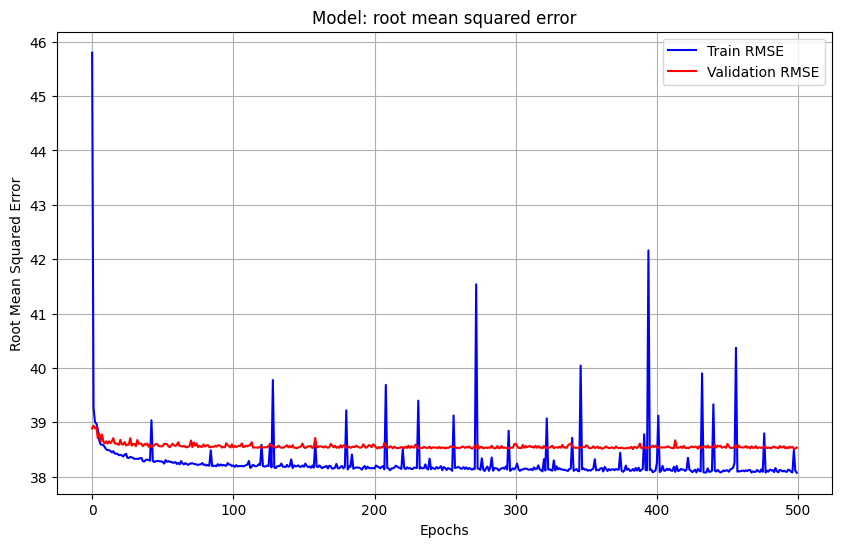

In [ ]:
# Display RMSE error for Train and Validation set 

print("training error rate %: ", 100 * history.history['root_mean_squared_error'][-1] / np.mean(ytrain_prepared))
print(history.history.keys())

epochs = list(range(800, 2000))
plt.figure(figsize=(10, 6))
plt.plot(history.history['root_mean_squared_error'],label='Train RMSE',color='blue')
plt.plot(history.history['val_root_mean_squared_error'],label='Validation RMSE',color='red')
plt.title(f'Model: root mean squared error')
plt.xlabel('Epochs')
plt.ylabel('Root Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# evaluation the final model

import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf

y_pred = model1.predict(Xtest_prepared)

# MAE (Mean Absolute Error)
mae = mean_absolute_error(ytest_prepared, y_pred)

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(ytest_prepared, y_pred))

# R² (R-squared)
r2 = r2_score(ytest_prepared, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")



367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step
MAE: 29.094618914428295
RMSE: 38.249103668548784
R²: 0.055234864269741
